In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        break

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mdjakirhossen/fruits-dataset-enhanced/Balanced_224/Fresh Bittermelon(1-3)/IMG_20251121_081555.jpg


/kaggle/input/datasets/mdjakirhossen/fruits-dataset-enhanced/Balanced_224/Semi fresh Pineapple (15-25)/aug_345_IMG-20251207-WA0029.jpg


/kaggle/input/datasets/mdjakirhossen/fruits-dataset-enhanced/Balanced_224/Rotten Papaya(7-12)/IMG_20260130_163521.jpg


/kaggle/input/datasets/mdjakirhossen/fruits-dataset-enhanced/Balanced_224/Rotten Cucumber(12-20)/aug_192_IMG_20260202_032701.jpg


/kaggle/input/datasets/mdjakirhossen/fruits-dataset-enhanced/Balanced_224/Fresh Tomato(1-10)/IMG_20251123_222918529_HDR.jpg


...

/kaggle/input/datasets/mdjakirhossen/fruits-dataset-enhanced/Balanced_224/Semi Fresh Papaya(4-7)/IMG_20251124_022608.jpg
/kaggle/input/datasets/mdjakirhossen/fruits-dataset-enhanced/Balanced_224/Semi_Fresh eggplant(4-8)/IMG_20251126_193446651_HDR.jpg


/kaggle/input/datasets/mdjakirhossen/fruits-dataset-enhanced/Balanced_224/Semi fresh Orange(9-20)/IMG_20251121_144613022_HDR_AE.jpg
/kaggle/input/datasets/mdjakirhossen/fruits-dataset-enhanced/Balanced_224/Semi fresh banana(4-7)/IMG_20251108_121322791_HDR_AE.jpg


/kaggle/input/datasets/mdjakirhossen/fruits-dataset-enhanced/Balanced_224/Rotten Orange(20-35)/aug_239_IMG-20251215-WA0016.jpg
/kaggle/input/datasets/mdjakirhossen/fruits-dataset-enhanced/Balanced_224/Semi fresh Tomato(10-24)/aug_129_IMG_20251122_210949997_HDR.jpg
/kaggle/input/datasets/mdjakirhossen/fruits-dataset-enhanced/Balanced_224/Rotten eggplant(8-15)/aug_41_IMG_20251118_165252874_HDR.jpg


/kaggle/input/datasets/mdjakirhossen/fruits-dataset-enhanced/Balanced_224/Rotten banana(7-13)/IMG_20251109_111958227_HDR_AE.jpg


/kaggle/input/datasets/mdjakirhossen/fruits-dataset-enhanced/Balanced_224/Semi Fresh Bittermelon ( 3-5)/aug_360_IMG_20260120_004752.jpg


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np

dataset_path = "/kaggle/input/datasets/mdjakirhossen/fruits-dataset-enhanced/Balanced_224"


In [3]:
image_data = []

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        for img in os.listdir(class_path):
            img_path = os.path.join(class_path, img)

            # Skip broken files or non-images
            if os.path.isfile(img_path):
                image_data.append([class_name, img_path])

df = pd.DataFrame(image_data, columns=["class", "image_path"])
df.head()


,class,image_path
0,Fresh Bittermelon(1-3),/kaggle/input/datasets/mdjakirhossen/fruits-da...
1,Fresh Bittermelon(1-3),/kaggle/input/datasets/mdjakirhossen/fruits-da...
2,Fresh Bittermelon(1-3),/kaggle/input/datasets/mdjakirhossen/fruits-da...
3,Fresh Bittermelon(1-3),/kaggle/input/datasets/mdjakirhossen/fruits-da...
4,Fresh Bittermelon(1-3),/kaggle/input/datasets/mdjakirhossen/fruits-da...


In [4]:
print("Total Classes:", df['class'].nunique())
print("Total Images:", len(df))

df['class'].value_counts()


Total Classes: 24
Total Images: 14160


class
Fresh Bittermelon(1-3)           590
Semi fresh Pineapple (15-25)     590
Rotten Papaya(7-12)              590
Rotten Cucumber(12-20)           590
Fresh Tomato(1-10)               590
Fresh Papaya(1-4)                590
Fresh eggplant(1-4)              590
Semi Fresh Cucumber(6-12)        590
Rotten Pineapple(25-35)          590
Fresh Cucumber(1-6)              590
Rotten Bittermelon(5-8)          590
Fresh pineapple(1-15)            590
Rotten Tomato(24-35)             590
Fresh Orange(1-9)                590
Fresh Banana(1-4)                590
Semi Fresh Papaya(4-7)           590
Semi_Fresh eggplant(4-8)         590
Semi fresh Orange(9-20)          590
Semi fresh banana(4-7)           590
Rotten Orange(20-35)             590
Semi fresh Tomato(10-24)         590
Rotten eggplant(8-15)            590
Rotten banana(7-13)              590
Semi Fresh Bittermelon ( 3-5)    590
Name: count, dtype: int64

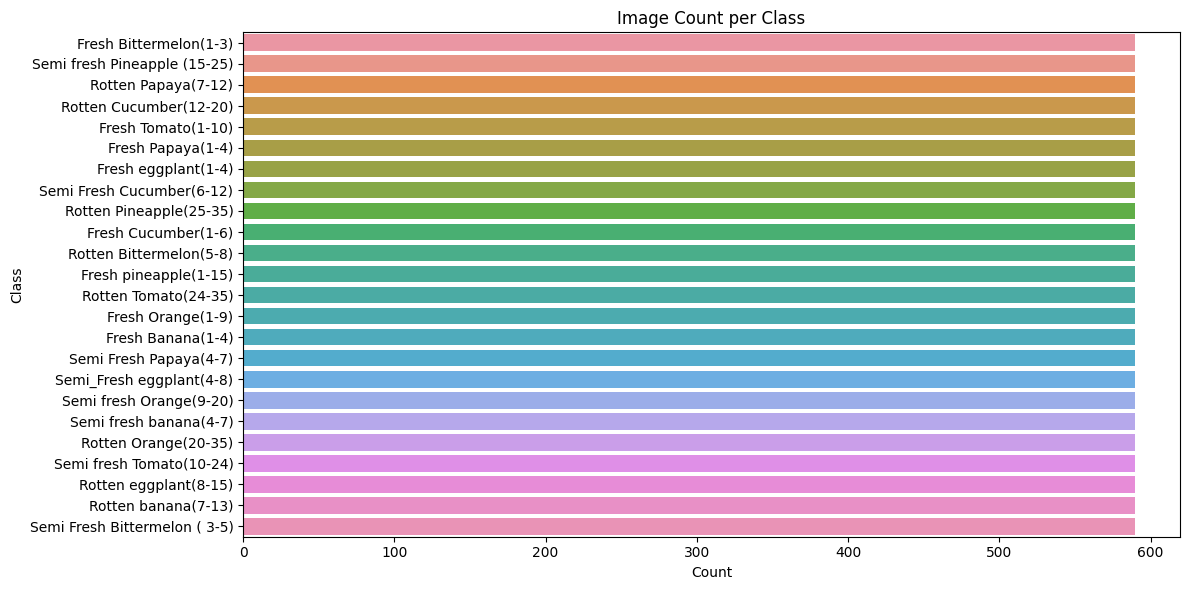

In [5]:
plt.figure(figsize=(12,6))
sns.countplot(y=df['class'], order=df['class'].value_counts().index)
plt.title("Image Count per Class")
plt.xlabel("Count")
plt.ylabel("Class")
plt.tight_layout()
plt.show()


In [6]:
def get_freshness(text):
    text = text.lower()
    if "fresh " in text and "semi" not in text:
        return "Fresh"
    elif "semi" in text:
        return "Semi-Fresh"
    elif "rotten" in text:
        return "Rotten"
    return "Unknown"

df["freshness_level"] = df["class"].apply(get_freshness)
df.head()


,class,image_path,freshness_level
0,Fresh Bittermelon(1-3),/kaggle/input/datasets/mdjakirhossen/fruits-da...,Fresh
1,Fresh Bittermelon(1-3),/kaggle/input/datasets/mdjakirhossen/fruits-da...,Fresh
2,Fresh Bittermelon(1-3),/kaggle/input/datasets/mdjakirhossen/fruits-da...,Fresh
3,Fresh Bittermelon(1-3),/kaggle/input/datasets/mdjakirhossen/fruits-da...,Fresh
4,Fresh Bittermelon(1-3),/kaggle/input/datasets/mdjakirhossen/fruits-da...,Fresh


In [7]:
def get_fruit(text):
    text = text.lower().strip()
    
    if "bittermelon" in text:
        return "Bittermelon"
    elif "pineapple" in text:
        return "Pineapple"
    elif "papaya" in text:
        return "Papaya"
    elif "cucumber" in text:
        return "Cucumber"
    elif "tomato" in text:
        return "Tomato"
    elif "eggplant" in text:
        return "Eggplant"
    elif "orange" in text:
        return "Orange"
    elif "banana" in text:
        return "Banana"
    else:
        return "Unknown"

# Apply
df["fruit_class"] = df["class"].apply(get_fruit)

df.head()

,class,image_path,freshness_level,fruit_class
0,Fresh Bittermelon(1-3),/kaggle/input/datasets/mdjakirhossen/fruits-da...,Fresh,Bittermelon
1,Fresh Bittermelon(1-3),/kaggle/input/datasets/mdjakirhossen/fruits-da...,Fresh,Bittermelon
2,Fresh Bittermelon(1-3),/kaggle/input/datasets/mdjakirhossen/fruits-da...,Fresh,Bittermelon
3,Fresh Bittermelon(1-3),/kaggle/input/datasets/mdjakirhossen/fruits-da...,Fresh,Bittermelon
4,Fresh Bittermelon(1-3),/kaggle/input/datasets/mdjakirhossen/fruits-da...,Fresh,Bittermelon


In [8]:
print(df["fruit_class"].value_counts())
print(df["freshness_level"].value_counts())

fruit_class
Bittermelon    1770
Pineapple      1770
Papaya         1770
Cucumber       1770
Tomato         1770
Eggplant       1770
Orange         1770
Banana         1770
Name: count, dtype: int64
freshness_level
Fresh         4720
Semi-Fresh    4720
Rotten        4720
Name: count, dtype: int64


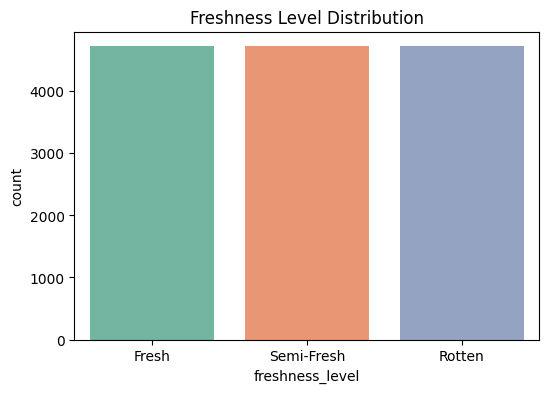

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["freshness_level"], palette="Set2")
plt.title("Freshness Level Distribution")
plt.show()


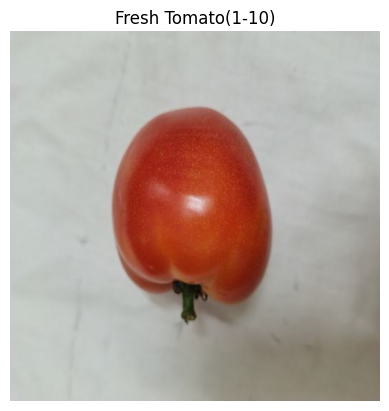

In [10]:
def show_samples(df, class_name, n=1):
    sample = df[df["class"] == class_name].sample(n)
    for idx, row in sample.iterrows():
        img = Image.open(row["image_path"])
        plt.imshow(img)
        plt.title(row["class"])
        plt.axis("off")
        plt.show()

# Example
show_samples(df, "Fresh Tomato(1-10)")



Sample images for: Fresh


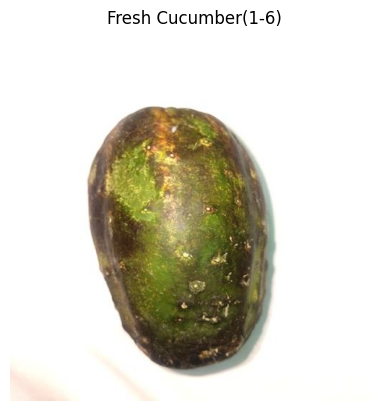

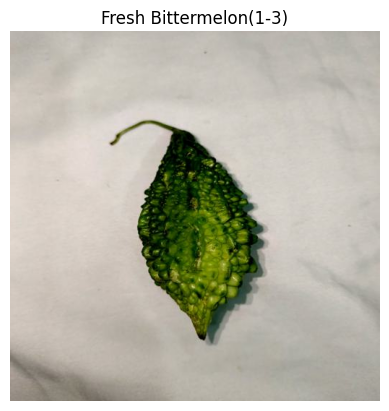

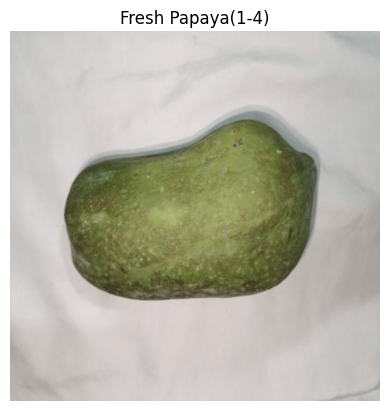


Sample images for: Semi-Fresh


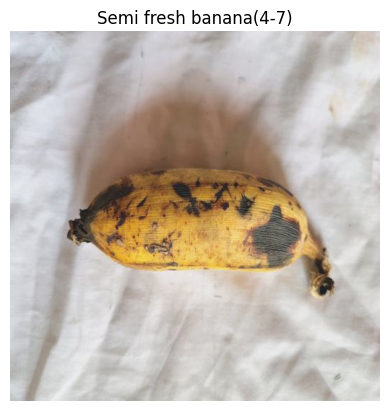

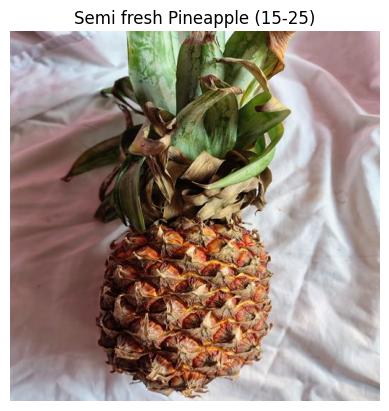

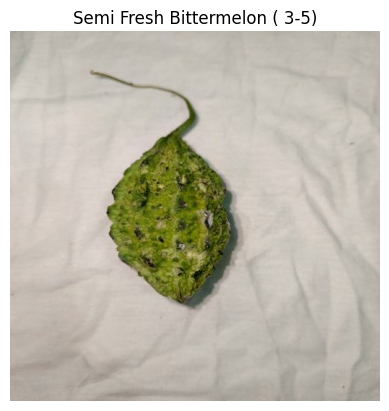


Sample images for: Rotten


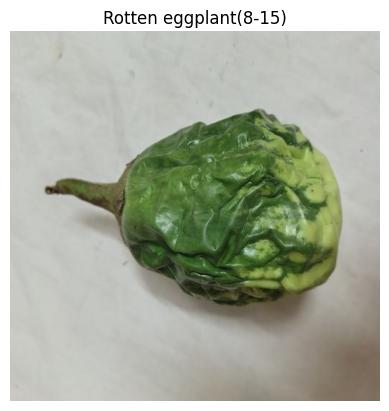

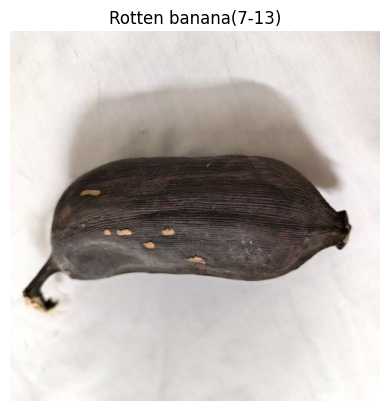

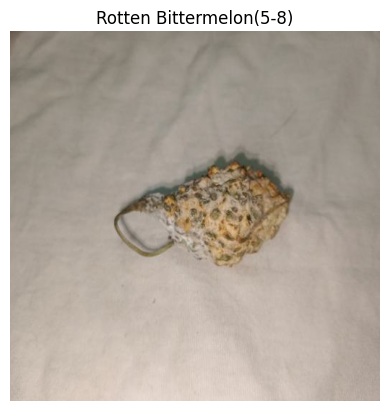

In [11]:
for level in ["Fresh", "Semi-Fresh", "Rotten"]:
    temp = df[df["freshness_level"] == level].sample(3)
    print(f"\nSample images for: {level}")

    for _, row in temp.iterrows():
        img = Image.open(row["image_path"])
        plt.imshow(img)
        plt.title(row["class"])
        plt.axis("off")
        plt.show()


In [12]:
df["filename"] = df["image_path"].apply(lambda x: os.path.basename(x))
duplicates = df[df["filename"].duplicated(keep=False)]
duplicates.head()


,class,image_path,freshness_level,fruit_class,filename
3556,Fresh eggplant(1-4),/kaggle/input/datasets/mdjakirhossen/fruits-da...,Fresh,Eggplant,eggplant(10).jpeg
3568,Fresh eggplant(1-4),/kaggle/input/datasets/mdjakirhossen/fruits-da...,Fresh,Eggplant,eggplant(7).jpeg
3603,Fresh eggplant(1-4),/kaggle/input/datasets/mdjakirhossen/fruits-da...,Fresh,Eggplant,eggplant(2).jpeg
3656,Fresh eggplant(1-4),/kaggle/input/datasets/mdjakirhossen/fruits-da...,Fresh,Eggplant,eggplant.jpeg
3774,Fresh eggplant(1-4),/kaggle/input/datasets/mdjakirhossen/fruits-da...,Fresh,Eggplant,eggplant(3).jpeg


In [13]:
summary = df.groupby("freshness_level")["image_path"].count().reset_index()
summary.columns = ["Freshness Level", "Image Count"]
summary


,Freshness Level,Image Count
0,Fresh,4720
1,Rotten,4720
2,Semi-Fresh,4720


In [14]:
df.head()

,class,image_path,freshness_level,fruit_class,filename
0,Fresh Bittermelon(1-3),/kaggle/input/datasets/mdjakirhossen/fruits-da...,Fresh,Bittermelon,IMG_20251121_081555.jpg
1,Fresh Bittermelon(1-3),/kaggle/input/datasets/mdjakirhossen/fruits-da...,Fresh,Bittermelon,IMG_20260120_004858.jpg
2,Fresh Bittermelon(1-3),/kaggle/input/datasets/mdjakirhossen/fruits-da...,Fresh,Bittermelon,aug_86_IMG_20260116_030227.jpg
3,Fresh Bittermelon(1-3),/kaggle/input/datasets/mdjakirhossen/fruits-da...,Fresh,Bittermelon,IMG_20260114_010513.jpg
4,Fresh Bittermelon(1-3),/kaggle/input/datasets/mdjakirhossen/fruits-da...,Fresh,Bittermelon,aug_222_IMG_20251118_160810.jpg


# Apply Model

In [15]:
!pip install torchcam


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/363.4 MB ? eta -:--:--

   ━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/363.4 MB 163.6 MB/s eta 0:00:03

   ━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.9/363.4 MB 246.0 MB/s eta 0:00:02

   ━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/363.4 MB 253.5 MB/s eta 0:00:02

   ━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.1/363.4 MB 161.9 MB/s eta 0:00:03

...

      Successfully uninstalled nvidia-cudnn-cu12-9.3.0.75


  Attempting uninstall: nvidia-cusolver-cu12


    Found existing installation: nvidia-cusolver-cu12 11.6.3.83
    Uninstalling nvidia-cusolver-cu12-11.6.3.83:


      Successfully uninstalled nvidia-cusolver-cu12-11.6.3.83


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
libcugraph-cu12 25.6.0 requires libraft-cu12==25.6.*, but you have libraft-cu12 25.2.0 which is incompatible.
pylibcugraph-cu12 25.6.0 requires pylibraft-cu12==25.6.*, but you have pylibraft-cu12 25.2.0 which is incompatible.
pylibcugraph-cu12 25.6.0 requires rmm-cu12==25.6.*, but you have rmm-cu12 25.2.0 which is incompatible.


In [16]:
# ================= IMPORTS =================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import timm
import pandas as pd
from PIL import Image
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [17]:
# ================= DATASET =================
class FruitDataset(Dataset):
    def __init__(self, df, target_col, transform=None):
        self.df = df
        self.target_col = target_col
        self.transform = transform
        self.labels = df[target_col].unique().tolist()
        self.label2idx = {label: idx for idx, label in enumerate(self.labels)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = self.label2idx[row[self.target_col]]
        return img, label

In [18]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def get_dataloader(df, target_col, batch_size=32):
    dataset = FruitDataset(df, target_col, transform=transform)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True), dataset.labels

In [19]:
# ================= MODELS =================
def get_models(num_classes):
    models_dict = {}

    effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    effnet.classifier[1] = nn.Linear(1280, num_classes)
    models_dict['EfficientNet'] = effnet

    densenet = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    densenet.classifier = nn.Linear(1024, num_classes)
    models_dict['DenseNet'] = densenet

    vit = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=num_classes)
    models_dict['ViT'] = vit

    mobilenet = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
    mobilenet.classifier[3] = nn.Linear(mobilenet.classifier[3].in_features, num_classes)
    models_dict['MobileNet'] = mobilenet

    return models_dict

In [20]:
# ================= TRAINING =================
def train_model(model, dataloader, val_loader, epochs=5, lr=1e-4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        # ===== TRAIN =====
        model.train()
        running_loss, correct, total = 0, 0, 0

        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total

        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        # ===== VALIDATION =====
        model.eval()
        val_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)

                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * imgs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= total
        val_acc = correct / total

        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} "
              f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # ===== PLOTS =====
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.legend()
    plt.title("Loss Curve")
    plt.show()

    plt.figure()
    plt.plot(train_accs, label="Train Accuracy")
    plt.plot(val_accs, label="Val Accuracy")
    plt.legend()
    plt.title("Accuracy Curve")
    plt.show()

    return model



In [21]:
# ================= EVALUATION =================
def evaluate_model(model, dataloader, labels_list):
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)

            preds.extend(predicted.cpu().numpy())
            targets.extend(labels.numpy())

    print("\nClassification Report:\n")
    print(classification_report(targets, preds, target_names=labels_list))

    cm = confusion_matrix(targets, preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_list, yticklabels=labels_list)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()



Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


  0%|          | 0.00/20.5M [00:00<?, ?B/s]

 66%|██████▌   | 13.5M/20.5M [00:00<00:00, 142MB/s]

100%|██████████| 20.5M/20.5M [00:00<00:00, 162MB/s]

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


...

Epoch 46/50 Train Loss: 0.0125 Acc: 0.9965 | Val Loss: 0.0025 Acc: 0.9988


Epoch 47/50 Train Loss: 0.0059 Acc: 0.9975 | Val Loss: 0.0025 Acc: 0.9987


Epoch 48/50 Train Loss: 0.0060 Acc: 0.9974 | Val Loss: 0.0024 Acc: 0.9987


Epoch 49/50 Train Loss: 0.0068 Acc: 0.9975 | Val Loss: 0.0027 Acc: 0.9988


Epoch 50/50 Train Loss: 0.0041 Acc: 0.9981 | Val Loss: 0.0024 Acc: 0.9988


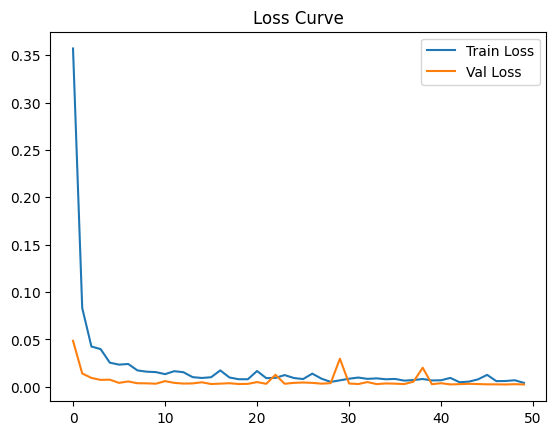

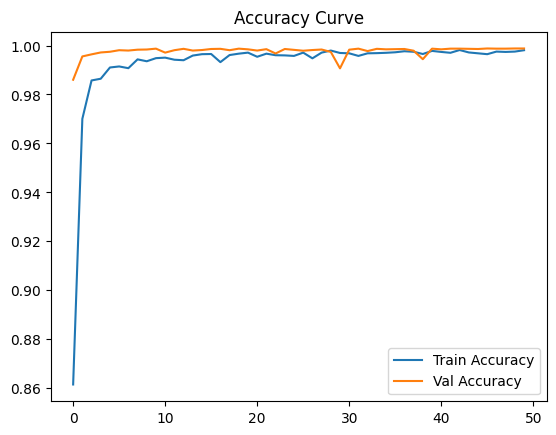


📊 Evaluating EfficientNet (Freshness)



Classification Report:

              precision    recall  f1-score   support

       Fresh       1.00      1.00      1.00      4720
  Semi-Fresh       1.00      1.00      1.00      4720
      Rotten       1.00      1.00      1.00      4720

    accuracy                           1.00     14160
   macro avg       1.00      1.00      1.00     14160
weighted avg       1.00      1.00      1.00     14160



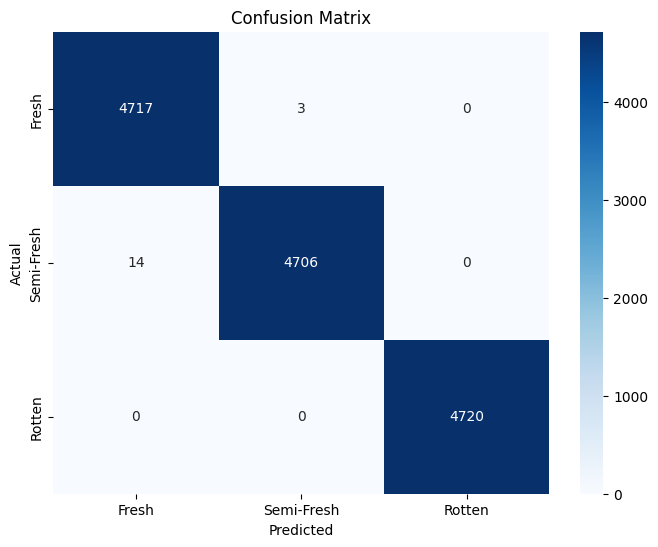


🔥 Training DenseNet for Freshness


Epoch 1/50 Train Loss: 0.2361 Acc: 0.9140 | Val Loss: 0.0385 Acc: 0.9910


Epoch 2/50 Train Loss: 0.0485 Acc: 0.9850 | Val Loss: 0.0399 Acc: 0.9865


Epoch 3/50 Train Loss: 0.0417 Acc: 0.9859 | Val Loss: 0.0219 Acc: 0.9918


Epoch 4/50 Train Loss: 0.0279 Acc: 0.9913 | Val Loss: 0.0084 Acc: 0.9977


...

Epoch 46/50 Train Loss: 0.0049 Acc: 0.9980 | Val Loss: 0.0069 Acc: 0.9980


Epoch 47/50 Train Loss: 0.0184 Acc: 0.9939 | Val Loss: 0.0030 Acc: 0.9984


Epoch 48/50 Train Loss: 0.0042 Acc: 0.9980 | Val Loss: 0.0026 Acc: 0.9986


Epoch 49/50 Train Loss: 0.0030 Acc: 0.9984 | Val Loss: 0.0026 Acc: 0.9987


Epoch 50/50 Train Loss: 0.0033 Acc: 0.9982 | Val Loss: 0.0121 Acc: 0.9965


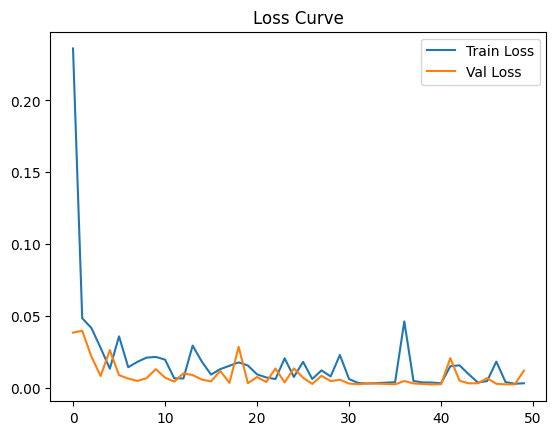

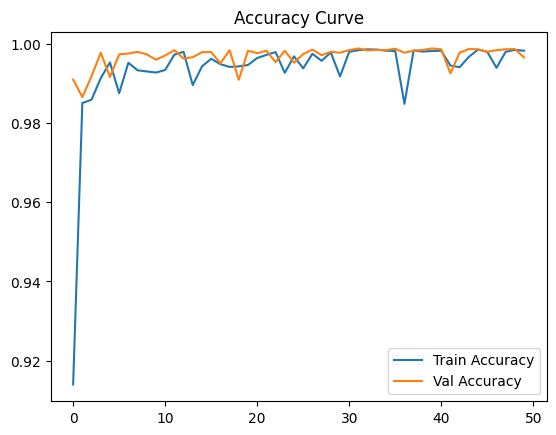


📊 Evaluating DenseNet (Freshness)



Classification Report:

              precision    recall  f1-score   support

       Fresh       0.99      1.00      1.00      4720
  Semi-Fresh       1.00      0.99      0.99      4720
      Rotten       1.00      1.00      1.00      4720

    accuracy                           1.00     14160
   macro avg       1.00      1.00      1.00     14160
weighted avg       1.00      1.00      1.00     14160



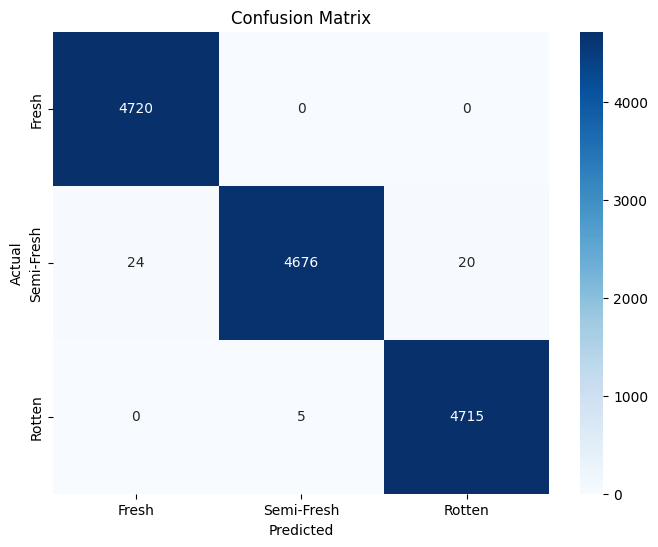


🔥 Training ViT for Freshness


Epoch 1/50 Train Loss: 0.3749 Acc: 0.8460 | Val Loss: 0.1486 Acc: 0.9494


Epoch 2/50 Train Loss: 0.1204 Acc: 0.9582 | Val Loss: 0.0535 Acc: 0.9819


Epoch 3/50 Train Loss: 0.0778 Acc: 0.9731 | Val Loss: 0.1002 Acc: 0.9668


Epoch 4/50 Train Loss: 0.0544 Acc: 0.9816 | Val Loss: 0.0629 Acc: 0.9753


...

Epoch 39/50 Train Loss: 0.0164 Acc: 0.9937 | Val Loss: 0.0199 Acc: 0.9930


Epoch 40/50 Train Loss: 0.0184 Acc: 0.9934 | Val Loss: 0.0043 Acc: 0.9980


Epoch 41/50 Train Loss: 0.0164 Acc: 0.9946 | Val Loss: 0.0385 Acc: 0.9847


Epoch 42/50 Train Loss: 0.0175 Acc: 0.9934 | Val Loss: 0.0038 Acc: 0.9981


Epoch 43/50 Train Loss: 0.0182 Acc: 0.9934 | Val Loss: 0.0412 Acc: 0.9857


In [22]:
# ================= TRAINING PIPELINE =================

# Freshness
fresh_loader, fresh_labels = get_dataloader(df, "freshness_level")
val_loader, _ = get_dataloader(df, "freshness_level")

fresh_models = get_models(len(fresh_labels))

for name, model in fresh_models.items():
    print(f"\n🔥 Training {name} for Freshness")
    trained_model = train_model(model, fresh_loader, val_loader, epochs=50)

    torch.save(trained_model.state_dict(), f"{name}_freshness.pth")

    print(f"\n📊 Evaluating {name} (Freshness)")
    evaluate_model(trained_model, val_loader, fresh_labels)



In [ ]:
# Fruit Classification
fruit_loader, fruit_labels = get_dataloader(df, "fruit_class")
val_loader, _ = get_dataloader(df, "fruit_class")

fruit_models = get_models(len(fruit_labels))

for name, model in fruit_models.items():
    print(f"\n🍎 Training {name} for Fruit Classification")
    trained_model = train_model(model, fruit_loader, val_loader, epochs=50)

    torch.save(trained_model.state_dict(), f"{name}_fruit.pth")

    print(f"\n📊 Evaluating {name} (Fruit)")
    evaluate_model(trained_model, val_loader, fruit_labels)